# SoilSpecDL

> Deep learning for soil infrared spectra, built on fastai

SoilSpecDL trains deep learning models on soil infrared spectra. It builds [fastai](https://www.fast.ai/) `DataLoaders` from spectra and soil properties, and provides 1D convolutional neural networks (CNNs) for spectra, including the architecture of [Albinet et al. (2022)](https://doi.org/10.1016/j.aiia.2022.10.001). Any fastai `Learner` can then train them, with fastai's learning rate finder, one-cycle training and callbacks.

SoilSpecDL follows the fastai philosophy: state-of-the-art deep learning should be accessible to domain scientists, not just to machine learning practitioners. If you are a soil scientist who uses R packages like `resemble` or `prospectr`, this package is designed with you in mind. Training a CNN on a large MIR spectral library should take a few lines of code, not a PhD in machine learning.

SoilSpecDL is part of a Python ecosystem for soil spectroscopy:

- [SoilSpecData](https://fr.anckalbi.net/soilspecdata/) loads the Open Soil Spectral Library (OSSL) as spectra and soil properties ready for machine learning.
- [SoilSpecTfm](https://fr.anckalbi.net/soilspectfm/) preprocesses spectra with scikit-learn transformers.
- SoilSpecDL trains deep learning models on them.

## Installation

``` sh
pip install -U soilspecdl
```

To install the development version, with nbdev, run this in the project root with [uv](https://docs.astral.sh/uv/):

``` sh
uv sync --extra dev
```

## Quick start

`from soilspecdl.all import *` imports every SoilSpecDL function and class. Each also has its own module, such as `soilspecdl.models`, for explicit imports. The fastai imports show what SoilSpecDL uses from fastai: the `Learner`, a loss, a metric, and the training schedule that adds `fit_one_cycle` and `lr_find`.

This example predicts exchangeable potassium (Kex) from the MIR spectra of the Open Soil Spectral Library (OSSL). [SoilSpecData](https://fr.anckalbi.net/soilspecdata/) gives the spectra and Kex values of every OSSL sample that has both. The first call to `load_ossl` downloads about 1 GB, and loading needs about 12 GB of memory. The example preprocesses the spectra with standard normal variate (SNV) and a first derivative, and log-transforms Kex, whose distribution is skewed. Then it trains `MirzaiCNN`, the CNN of [Albinet et al. (2022)](https://doi.org/10.1016/j.aiia.2022.10.001):


In [ ]:
#| eval: false
import numpy as np
from sklearn.pipeline import Pipeline
from soilspecdata.all import *
from soilspectfm.all import *
from fastai.learner import Learner
from fastai.losses import MSELossFlat
from fastai.metrics import R2Score
from fastai.callback.schedule import *
from soilspecdl.all import *


In [ ]:
#| eval: false
mir = load_ossl().mir()
X, y, ids = mir.xy('k.ext_usda.a725_cmolc.kg')
pipe = Pipeline([
    ('snv', SNV()),
    ('deriv', SavitzkyGolay(deriv=1))])
X_tfm = pipe.fit_transform(X)
y_tfm = np.log1p(y.flatten())

`get_spectral_dls` splits the samples into train, validation and test sets, and returns the fastai `DataLoaders` and the test set's indices. `StandardizeSpectrum` rescales each spectrum after the derivative has shrunk it, to the scale a CNN's weight initialization expects. Each spectrum in a batch plots against its wavenumbers:

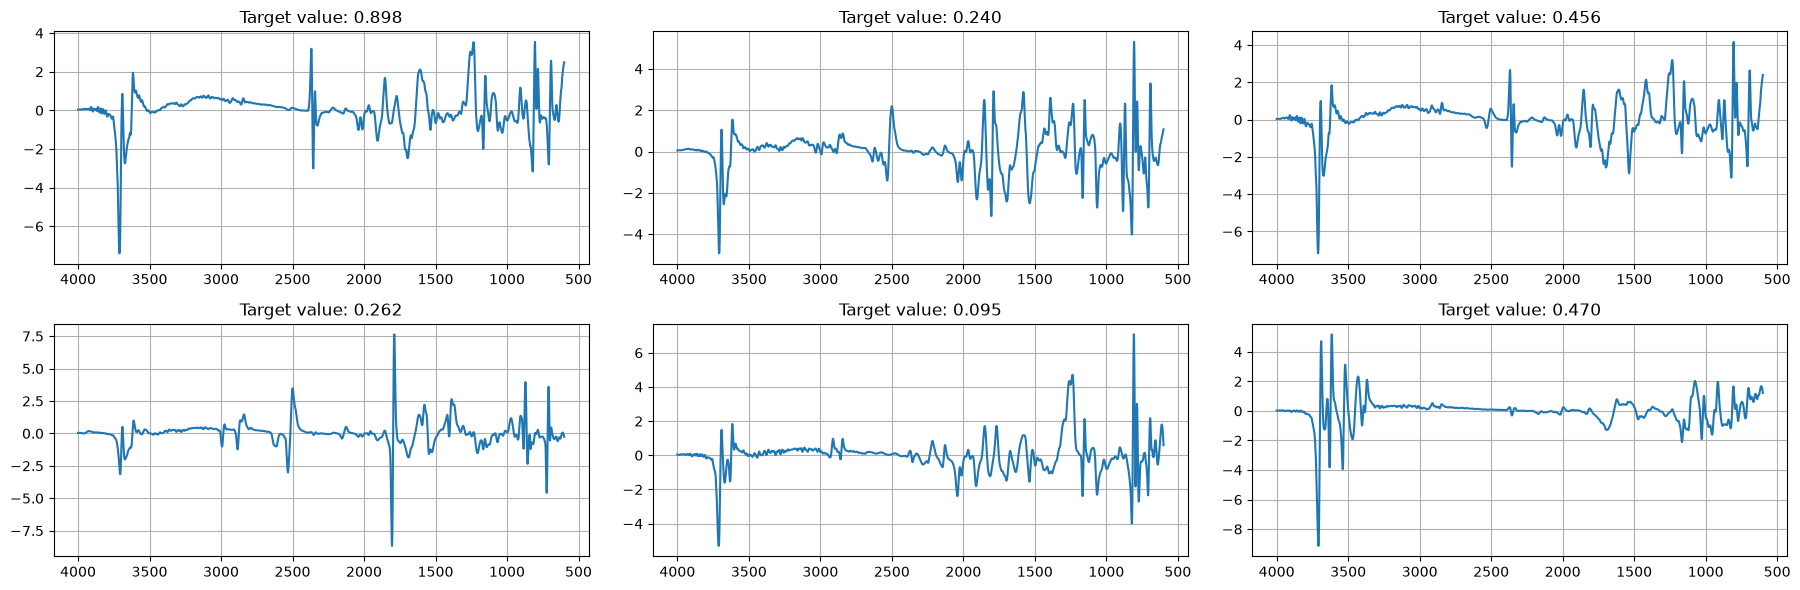

In [ ]:
#| eval: false
dls, test_idx = get_spectral_dls(
    X_tfm, y_tfm, mir.wavenumbers,
    batch_tfms=[StandardizeSpectrum()])
dls.show_batch(max_n=6, ncols=3)

Train `MirzaiCNN` with a fastai `Learner`, with mean squared error as the loss and R² as the metric:

In [ ]:
#| eval: false
learn = Learner(
    dls, MirzaiCNN(),
    loss_func=MSELossFlat(),
    metrics=R2Score())

Find a learning rate, then train:

<div></div>

SuggestedLRs(valley=0.0010000000474974513)

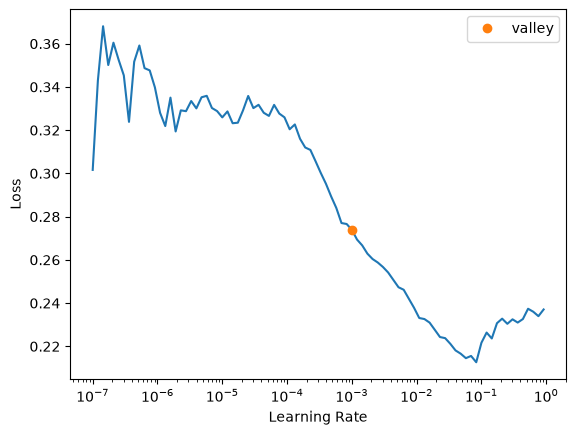

In [ ]:
#| eval: false
learn.lr_find()

In [ ]:
#| eval: false
learn.fit_one_cycle(20, lr_max=1e-3)

epoch,train_loss,valid_loss,r2_score,time
0,0.095762,0.075750,0.464282,00:07
1,0.075270,0.065856,0.534250,00:08
2,0.067920,0.217066,-0.535135,00:08
3,0.065452,0.174799,-0.236214,00:08
4,0.056049,0.107070,0.242781,00:08
5,0.052376,0.064878,0.541171,00:07
6,0.051645,0.072169,0.489606,00:08
7,0.052505,0.051545,0.635461,00:08
8,0.043817,0.095978,0.321224,00:07
9,0.043177,0.038569,0.727231,00:08


## Upgrading from 0.0.x

Version 0.1.0 changes the API of `soilspecdl`. To update code written for version 0.0.x:

- `MirzaiCNN` is now a function that returns a `SpectralCNN`. It no longer accepts `out_channel` or `conv_block_cls`. Weights saved from version 0.0.x load unchanged.
- `FeatureExtractor` takes the output channels of each block as `nfs`, instead of `out_channel` and `n_layers`. It returns `(batch, channels)` instead of `(batch, channels, 1)`.
- `SpectralBlock()` is now `SpectralBlock(wns)`.
- The `TensorSpectrum.wns` class attribute is gone. Each spectrum carries its wavenumbers in `wns`, and `get_spectral_dls` stores them once in `dls.wns`.
- `get_spectral_dls` raises a `ValueError` when `wns` does not have one value per column of `X`.
- `get_splitter` raises a `ValueError` when `train_pct + valid_pct` exceeds 1. Before, its check could never fail.
- `get_fuku_cs137`, `ConvBlockBaseline`, `RegressionFloatBlock`, `SpectralTarget`, `cnt_params`, `get_mir_k_1k_smp` and the `soilspecdl.core` module are gone. To count a model's parameters, use fastai's `learn.summary()`. For example data, use `load_toy_kssl`.
- SoilSpecDL now requires SoilSpecData 0.2.1 or later, and SoilSpecTfm 0.1.1 or later.

## Contributing

Contributions are welcome. SoilSpecDL is built with [nbdev](https://nbdev.fast.ai/): the notebooks in `nbs/` are the source of the code, the documentation and the tests. After changing a notebook, export the code, run the tests, clean the notebooks and rebuild the README with:

``` sh
uv run nbdev-prepare
```

Report bugs and ask questions in [GitHub issues](https://github.com/franckalbinet/soilspecdl/issues).

## License

SoilSpecDL is under the [Apache 2.0](LICENSE) licence. The toy dataset comes from OSSL, which publishes KSSL data under [CC BY 4.0](https://creativecommons.org/licenses/by/4.0/).